# Demonstration of using COLIBRE particle data and SOAP catalogues

### I use the SWIFTgalaxy package to read in and manipulate particle data from the COLIBRE snapshots to calculate halo binding energies ($E_{\rm bind}$) at different apertures.

### These calculated $E_{\rm bind}$ values are then compared to the $E_{\rm bind}$ values from SOAP, a post-processing method for computing galaxy and halo properties.

### Different plots illustrating these comparisons will be shown that demonstrate relationships between $E_{\rm bind}$ and various galaxy properties. 

## Initialisation and COLIBRE simulation data loading using swiftsimio and precomputed matching arrays

In [1]:
import numpy as np
import pandas as pd
import h5py as h5
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import swiftsimio as sw
from swiftgalaxy import SWIFTGalaxies, SOAP, MaskCollection
import matplotlib.pyplot as plt
import unyt as u
from astropy.cosmology import FlatLambdaCDM
from statsmodels.nonparametric.smoothers_lowess import lowess

import os
import sys
sys.path.append("OU-Example-Code/COLIBRE-Research")

from Util.spearman_window import spearman_track_ebind
from Util.median_spread import median_spread

plt.style.use('mnras_mpl.stylesheet')

cosmology = FlatLambdaCDM(H0=68.10, Om0=0.3089)
h = 0.681
Msun = 1.98841e33
yr = 3.154e7
Mpc = 3.086e24 
kpc = 3.086e21
G = 6.67e-8
km = 1e5
kms = 1e5
cgs_conv_mass = 1.989e+43
cgs_conv_vel = 100000
cgs_conv_radius = 3.085678e+21
cgs_conv_factor_ebind = 1.98841e+53

base_path = COLIBRE_path
run_l200m6 = 'L200_m6/Thermal'
run_l200m6_DMO = 'L200_m6/DMO'

matching_filepath = matching_filepath

save_path = save_path

In [2]:
# The haloes in the DMO and Hydro runs need to be paired using a bijective mathcing routine
# I load in arrays containing the bijective matching indices that I have pre-computed
with h5.File(f'{save_path}/DMO_Hydro_Matching.hdf5', 'r') as fi:
    bijective_idx_DMO = fi['Bijective_DMO_Indices'][()]
    bijective_idx_Hydro = fi['Bijective_Hydro_Indices'][()]
    consistent_DMOtoHydro = fi['consistent_DMOtoHydro'][()]
    consistent_HydrotoDMO = fi['consistent_HydrotoDMO'][()]
fi.close()

# Load pre-computed SOAP binding energies for the DMO sim
with h5.File(f'{save_path}/DMO_Binding_Energies.hdf5', 'r') as fi:
    ebind_DMO = np.log10(fi['TotalBindingEnergy'][()])
fi.close()

# Initialise SOAP catalogues for the hydro and DMO runs using swiftsimio
data_l200m6 = sw.load(f'{base_path}/{run_l200m6}/SOAP-HBT/halo_properties_0127.hdf5')
virtual_snapshot_path = os.path.join(base_path, run_l200m6, 'SOAP-HBT/colibre_with_SOAP_membership_0127.hdf5')
soap_catalogue_path = os.path.join(base_path, run_l200m6, 'SOAP-HBT/halo_properties_0127.hdf5')

data_l200m6_DMO = sw.load(f'{base_path}/{run_l200m6_DMO}/SOAP-HBT/halo_properties_0127.hdf5')
DMO_virtual_snapshot_path = os.path.join(base_path, run_l200m6_DMO, 'SOAP-HBT/colibre_with_SOAP_membership_0127.hdf5')
DMO_soap_catalogue_path = os.path.join(base_path, run_l200m6_DMO, 'SOAP-HBT/halo_properties_0127.hdf5')

In [ ]:
# Compute and match the hydro sim binding energies to the DMO sim binding energies
soap_index = np.arange(len(data_l200m6.bound_subhalo.most_massive_black_hole_mass))[consistent_HydrotoDMO==1]
track_IDs = data_l200m6.input_halos_hbtplus.track_id.value[consistent_HydrotoDMO==1]

e_kin = data_l200m6.bound_subhalo.kinetic_energy_total[consistent_HydrotoDMO==1].value.astype(np.float64)
e_kin = e_kin * cgs_conv_factor_ebind
e_pot = data_l200m6.bound_subhalo.potential_energy_total[consistent_HydrotoDMO==1].value.astype(np.float64)
e_pot = e_pot * cgs_conv_factor_ebind
ebind_hydro = (e_kin + e_pot).astype(np.float64) 
ebind_hydro = np.log10(np.abs(ebind_hydro))

DMO_soap_index = np.arange(len(data_l200m6_DMO.bound_subhalo.centre_of_mass))[consistent_DMOtoHydro==1]
DMO_track_IDs = data_l200m6_DMO.input_halos_hbtplus.track_id.value[consistent_DMOtoHydro==1]

## To calculate $E_{\rm bind}$ at different apertures, I create a particle mask that is passed to SWIFTgalaxy and then perform the $E_{\rm bind}$ calculations on only the masked particles

In [ ]:
def corrected_ebind(sg, DMO=False):
    
    if DMO:
        # Pull DM mass
        dm_particle_mass = sg.metadata.initial_mass_table.dark_matter  # single value
        n_dm = len(sg.dark_matter.coordinates)
        dm_masses = np.full(n_dm, dm_particle_mass.to("g").value) * u.g
        
        # Calculate potential and kinetic terms for all particles
        PE_dm = (sg.dark_matter.potentials.astype(np.float64) * dm_masses.astype(np.float64)).to("erg")
        v_sq_dm = (sg.dark_matter.velocities.astype(np.float64) ** 2).sum(axis=1)
        KE_dm = (0.5 * dm_masses.astype(np.float64) * v_sq_dm).to("erg")
        
        # Mass array of particles
        all_masses = dm_masses.astype(np.float64).to("g")
        
        raw_total_PE = PE_dm.sum()
        total_KE = KE_dm.sum()
        
        # Grab all potentials for all particles
        all_potentials = np.concatenate([
            sg.dark_matter.potentials.astype(np.float64).to("erg/g"),
        ])
        
        # Grab all masses for all particles
        all_masses = np.concatenate([
            sg.dark_matter.masses.astype(np.float64).to("g"),
        ])
    else:
        # DM
        PE_dm = (sg.dark_matter.potentials.astype(np.float64) * 
                sg.dark_matter.masses.astype(np.float64)).to("erg")
        v_sq_dm = (sg.dark_matter.velocities.astype(np.float64) ** 2).sum(axis=1)
        KE_dm = (0.5 * sg.dark_matter.masses.astype(np.float64) * v_sq_dm).to("erg")
        
        # Gas
        PE_gas = (sg.gas.potentials.astype(np.float64) * 
                sg.gas.masses.astype(np.float64)).to("erg")
        v_sq_gas = (sg.gas.velocities.astype(np.float64) ** 2).sum(axis=1)
        KE_gas = (0.5 * sg.gas.masses.astype(np.float64) * v_sq_gas).to("erg")
        
        # Stars
        PE_stars = (sg.stars.potentials.astype(np.float64) * 
                    sg.stars.masses.astype(np.float64)).to("erg")
        v_sq_stars = (sg.stars.velocities.astype(np.float64) ** 2).sum(axis=1)
        KE_stars = (0.5 * sg.stars.masses.astype(np.float64) * v_sq_stars).to("erg")
        
        # Sum the potential and kinetic energies for all components
        raw_total_PE = PE_dm.sum() + PE_gas.sum() + PE_stars.sum()
        total_KE = KE_dm.sum() + KE_gas.sum() + KE_stars.sum()
        
        # Grab all potentials for all particles
        all_potentials = np.concatenate([
            sg.dark_matter.potentials.astype(np.float64).to("erg/g"),
            sg.gas.potentials.astype(np.float64).to("erg/g"),
            sg.stars.potentials.astype(np.float64).to("erg/g"),
        ])
        
        # Grab all masses for all particles
        all_masses = np.concatenate([
            sg.dark_matter.masses.astype(np.float64).to("g"),
            sg.gas.masses.astype(np.float64).to("g"),
            sg.stars.masses.astype(np.float64).to("g"),
        ])

    # Find the background potential and subtract from total potential
    phi_background = all_potentials[np.argmax(all_potentials)]
    total_bound_mass = all_masses.sum()
    total_PE = 0.5 * (raw_total_PE - (phi_background * total_bound_mass).to("erg"))
    
    # Sum terms to calculate total binding energy
    total_BE = np.log10(np.abs(total_PE + total_KE))

    return total_BE.astype(np.float32)

In [ ]:
# Mask the particles in the SWIFTGalaxies object based on the specified aperture
# Account for DMO and Hydro runs separately
def mask_radius(sg, aperture, DMO=False):
    if aperture == 'r200':
        r200 = sg.halo_catalogue.spherical_overdensity_200_crit.soradius
        if DMO:
            mask_collection = MaskCollection(
                dark_matter=sg.dark_matter.spherical_coordinates.r < r200,
            )
        else:
            mask_collection = MaskCollection(
                dark_matter=sg.dark_matter.spherical_coordinates.r < r200,
                gas=sg.gas.spherical_coordinates.r < r200,
                stars=sg.stars.spherical_coordinates.r < r200,
            )
            
    else:
        aperture = aperture * u.kpc
        if DMO:
            mask_collection = MaskCollection(
                dark_matter=sg.dark_matter.spherical_coordinates.r < aperture,
            )
        else:
            mask_collection = MaskCollection(
                dark_matter=sg.dark_matter.spherical_coordinates.r < aperture,
                gas=sg.gas.spherical_coordinates.r < aperture,
                stars=sg.stars.spherical_coordinates.r < aperture,
            )
            
    sg.mask_particles(mask_collection)
    BE = corrected_ebind(sg, DMO=DMO)
    return BE

In [ ]:
# Initialise SWIFTGalaxies object using the snapshot with SOAP membership information
sgs = SWIFTGalaxies(
        virtual_snapshot_path,
        SOAP(
            soap_catalogue_path,
            soap_index=soap_index,
            extra_mask=None
        )
)

# Run binding energy calculations for the DMO and Hydro runs at different apertures
e_bind_DMO_3kpc = sgs.map(lambda sg: mask_radius(sg, 3, DMO=True))
e_bind_DMO_30kpc = sgs.map(lambda sg: mask_radius(sg, 30, DMO=True))
e_bind_DMO_100kpc = sgs.map(lambda sg: mask_radius(sg, 100, DMO=True))
e_bind_DMO_r200 = sgs.map(lambda sg: mask_radius(sg, 'r200', DMO=True))

e_bind_hydro_3kpc = sgs.map(lambda sg: mask_radius(sg, 3))
e_bind_hydro_30kpc = sgs.map(lambda sg: mask_radius(sg, 30))
e_bind_hydro_100kpc = sgs.map(lambda sg: mask_radius(sg, 100))
e_bind_hydro_r200 = sgs.map(lambda sg: mask_radius(sg, 'r200'))

# Save to hdf5 file
with h5.File(f'{save_path}/Ebind_Aperture.hdf5', 'w') as fi:
    fi.create_dataset('DMO/3kpc', data=np.array(e_bind_DMO_3kpc, dtype=np.float32))
    fi.create_dataset('DMO/30kpc', data=np.array(e_bind_DMO_30kpc, dtype=np.float32))
    fi.create_dataset('DMO/100kpc', data=np.array(e_bind_DMO_100kpc, dtype=np.float32))
    fi.create_dataset('DMO/r200', data=np.array(e_bind_DMO_r200, dtype=np.float32))
    fi.create_dataset('Hydro/3kpc', data=np.array(e_bind_hydro_3kpc, dtype=np.float32))
    fi.create_dataset('Hydro/30kpc', data=np.array(e_bind_hydro_30kpc, dtype=np.float32))
    fi.create_dataset('Hydro/100kpc', data=np.array(e_bind_hydro_100kpc, dtype=np.float32))
    fi.create_dataset('Hydro/r200', data=np.array(e_bind_hydro_r200, dtype=np.float32))

In [16]:
# We'll use a combination of pre-computed data and data loaded from SOAP
with h5.File(f'{save_path}/soap_index.hdf5', 'r') as fi:
    soap_index_matching = fi['Soap_Index_Hydro'][()]
fi.close()

with h5.File(f'{f_exsitu_filepath}', 'r') as fi:
    f_exsitu = fi['/ExclusiveSphere/30kpc/ExSituFraction'][()]
fi.close()

with h5.File(f'{save_path}/galaxy_properties.hdf5', 'r') as fi:
    track_IDs_histories = fi['Track_IDs'][()]
    
    m200 = fi['M200_Tracks'][()][:,0]
    mbh = fi['MBH_Tracks'][()][:,0]
    kappa_stars = fi['Kappa_Stars_Tracks'][()][:,0]
    kappa_gas = fi['Kappa_Gas_Tracks'][()][:,0]
    psi_3kpc = fi['Misalignment_3kpc_Tracks'][()][:,0]
    psi_30kpc = fi['Misalignment_30kpc_Tracks'][()][:,0]
    psi_2r50 = fi['Misalignment_2r50_Tracks'][()][:,0]
fi.close()

with h5.File(f'{save_path}/Ebind_Apertures.hdf5', 'r') as fi:
    ebind_DMO_3kpc = fi['EbindDMO/3kpc'][()]
    ebind_DMO_30kpc = fi['EbindDMO/30kpc'][()]
fi.close()


# Build array of pre-computed data
X = pd.DataFrame({'MBH': mbh, 'M200': m200, 'KappaCoStars': kappa_stars, 'KappaCoGas': kappa_gas, 
                  'Psi3kpc': psi_3kpc, 'Psi30kpc': psi_30kpc, 'Psi2r50': psi_2r50,
                  'EbindDMO3kpc': ebind_DMO_3kpc, 'EbindDMO30kpc': ebind_DMO_30kpc})

print(X.shape)

(31364, 9)


In [17]:
# Load in SOAP properties, making sure to match using the bijective matching indices, and the galaxyIDs from pre-computed galaxies
# The pre-computed galaxies went through some data reduction - primarily a mass-cut of > 10^11.5Msun

soap_index = np.arange(len(data_l200m6.bound_subhalo.most_massive_black_hole_mass))[consistent_HydrotoDMO==1]
matching_idx = np.isin(soap_index, soap_index_matching)

f_exsitu = f_exsitu[consistent_HydrotoDMO==1][matching_idx]
ebind_DMO = ebind_DMO[matching_idx]

e_kin = data_l200m6.bound_subhalo.kinetic_energy_total[consistent_HydrotoDMO==1][matching_idx].value.astype(np.float64)
e_kin = e_kin * cgs_conv_factor_ebind
e_pot = data_l200m6.bound_subhalo.potential_energy_total[consistent_HydrotoDMO==1][matching_idx].value.astype(np.float64)
e_pot = e_pot * cgs_conv_factor_ebind
ebind_hydro = (e_kin + e_pot).astype(np.float64) 
ebind_hydro = np.log10(np.abs(ebind_hydro))

print(ebind_hydro.shape)

conc = data_l200m6.spherical_overdensity_200_crit.concentration[consistent_HydrotoDMO==1][matching_idx]

spin = data_l200m6.spherical_overdensity_200_crit.spin_parameter[consistent_HydrotoDMO==1][matching_idx]

mstar = data_l200m6.exclusive_sphere_30kpc.stellar_mass[consistent_HydrotoDMO==1][matching_idx]
mstar.convert_to_units('Msun')
mstar = np.log10(mstar.value)

stellar_spin = data_l200m6.exclusive_sphere_30kpc.angular_momentum_stars[consistent_HydrotoDMO==1][matching_idx]
stellar_spin.convert_to_units('kpc * km/s * Msun')
stellar_spin = stellar_spin.value
stellar_spin = np.sqrt(np.sum(stellar_spin**2, axis=1))
stellar_spin /= 10**mstar

X_SOAP = pd.DataFrame({'Conc': conc, 'Spin': spin,
                       'Mstar': mstar, 'StellarSpin': stellar_spin, 'fExSitu': f_exsitu,
                       'EbindHydro': ebind_hydro, 'EbindDMO': ebind_DMO})

print(X_SOAP.shape)
X = X.reset_index(drop=True)
X = pd.concat([X, X_SOAP], axis=1)
print(X)

X = X.sort_values('EbindDMO').reset_index(drop=True)


# Calculate LOWESS fit to MBH so we can remove the obvious outliers
#  Target BHs that are very likely to be a result of failed particle/halo tracking, rather than a physical process
lowess_mbh = lowess(X['MBH'], X['EbindDMO'], return_sorted=False, frac=0.2, it=3)
delta_mbh = X['MBH'] - lowess_mbh

drop_idx = [i for i in range(len(X)) if lowess_mbh[i] - X['MBH'].iloc[i] > 1.5]
X = X.drop(drop_idx).reset_index(drop=True)


# Calculate LOWESS medians of all columns and create 'Delta' values, representing the deviation from the median
delta_X = X.copy().drop(columns='EbindDMO').reset_index(drop=True)
lowess_X = X.copy().drop(columns='EbindDMO').reset_index(drop=True)
for key in X.keys()[:-1]:
    lowess_X[key] = lowess(X[key], X['EbindDMO'], return_sorted=False, frac=0.2, it=3)
    delta_X[key] = X[key] - lowess_X[key]
    
# Remove any NaNs
mask = ~np.isnan(delta_X).any(axis=1)
X = X[mask].reset_index(drop=True)
lowess_X = lowess_X[mask].reset_index(drop=True)
delta_X = delta_X[mask].reset_index(drop=True)


(31364,)
(31364, 7)
            MBH       M200  KappaCoStars  KappaCoGas   Psi3kpc  Psi30kpc  \
0      6.908308  12.015465      0.631836    0.519531  0.998559  0.999951   
1      6.292740  11.548697      0.553711    0.816406  0.999872  0.954389   
2      7.856080  12.251638      0.329102    0.401367  0.855670  0.991857   
3      7.679758  12.012837      0.628906    0.459473 -0.991948 -0.924051   
4      6.089147  11.577636      0.410156    0.942383  0.992099  0.949852   
...         ...        ...           ...         ...       ...       ...   
31359  7.335808  12.170995      0.634766    0.711914  0.999696  0.999371   
31360  5.904970  11.636613      0.793945    0.770508  0.998537  0.982492   
31361  7.367501  11.845873      0.281738    0.312500  0.605340  0.655980   
31362  5.832185  11.588972      0.670898    0.629883  0.999631  0.934674   
31363  7.327315  12.156095      0.364746    0.576172 -0.702738 -0.291067   

        Psi2r50  EbindDMO3kpc  EbindDMO30kpc       Conc      Spin  

In [29]:
ebind_bins, sr_arr_m200, p_arr_m200 = spearman_track_ebind(delta_X['M200'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_ebind_hydro, p_arr_ebind_hydro = spearman_track_ebind(delta_X['EbindHydro'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_ebind_DMO_3kpc, p_arr_ebind_DMO_3kpc = spearman_track_ebind(delta_X['EbindDMO3kpc'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_ebind_DMO_30kpc, p_arr_ebind_DMO_30kpc = spearman_track_ebind(delta_X['EbindDMO30kpc'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_psi_3kpc, p_arr_psi_3kpc = spearman_track_ebind(delta_X['Psi3kpc'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_psi_30kpc, p_arr_psi_30kpc = spearman_track_ebind(delta_X['Psi30kpc'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_psi_2r50, p_arr_psi_2r50 = spearman_track_ebind(delta_X['Psi2r50'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_spin, p_arr_spin = spearman_track_ebind(delta_X['Spin'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_conc, p_arr_conc = spearman_track_ebind(delta_X['Conc'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_mstar, p_arr_mstar = spearman_track_ebind(delta_X['Mstar'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_kappa_co_stars, p_arr_kappa_co_stars = spearman_track_ebind(delta_X['KappaCoStars'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_kappa_co_gas, p_arr_kappa_co_gas = spearman_track_ebind(delta_X['KappaCoGas'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_stellar_spin, p_arr_stellar_spin = spearman_track_ebind(delta_X['StellarSpin'], delta_X['MBH'], X['EbindDMO'])
_, sr_arr_f_exsitu, p_arr_f_exsitu = spearman_track_ebind(delta_X['fExSitu'], delta_X['MBH'], X['EbindDMO'])


_, mbh_25th, mbh_75th = median_spread(X['EbindDMO'], X['MBH'])

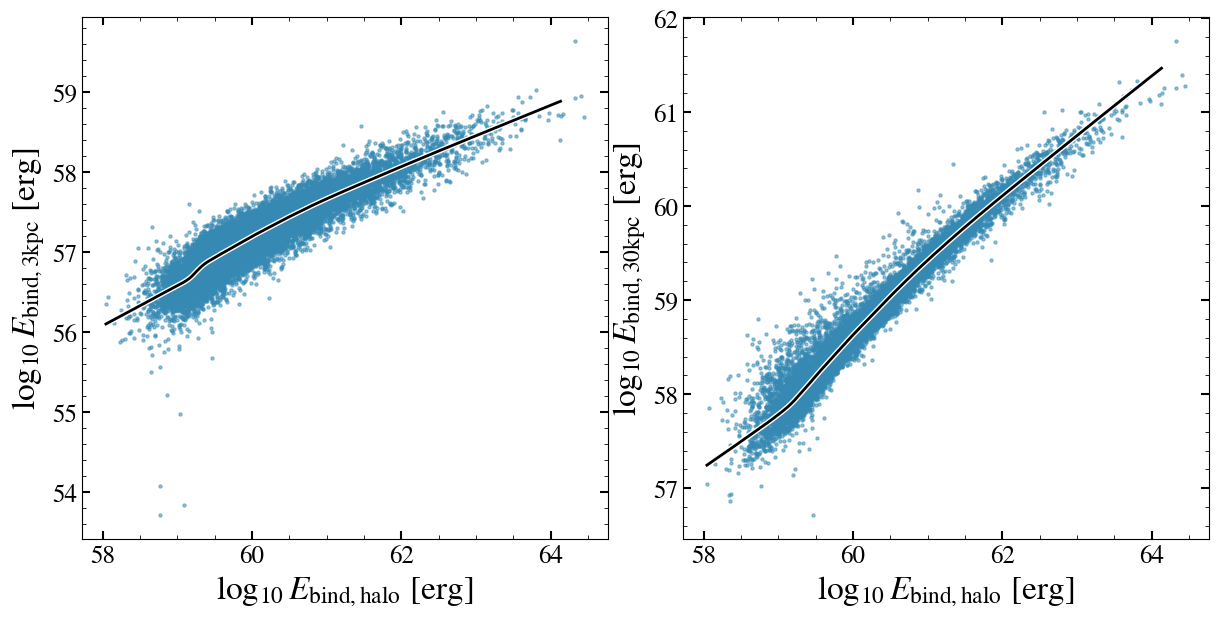

In [36]:
fig, ax = plt.subplots(1,2, figsize=(12,6), sharex=True, layout='compressed')

ax[0].scatter(X['EbindDMO'], X['EbindDMO3kpc'], s=5, c="#3589B3", alpha=0.5)
ax[0].plot(X['EbindDMO'][:-5], lowess_X['EbindDMO3kpc'][:-5], lw=4, c='w')
ax[0].plot(X['EbindDMO'][:-5], lowess_X['EbindDMO3kpc'][:-5], lw=2, c='k', label='LOWESS Median')
ax[0].set_xlabel('${\\rm log_{10}} \\, E_{\\rm bind, halo}$ [erg]')
ax[0].set_ylabel('${\\rm log_{10}} \\, E_{\\rm bind, 3kpc}$ [erg]')

ax[1].scatter(X['EbindDMO'], X['EbindDMO30kpc'], s=5, c="#3589B3", alpha=0.5)
ax[1].plot(X['EbindDMO'][:-5], lowess_X['EbindDMO30kpc'][:-5], lw=4, c='w')
ax[1].plot(X['EbindDMO'][:-5], lowess_X['EbindDMO30kpc'][:-5], lw=2, c='k', label='LOWESS Median')
ax[1].set_xlabel('${\\rm log_{10}} \\, E_{\\rm bind, halo}$ [erg]')
ax[1].set_ylabel('${\\rm log_{10}} \\, E_{\\rm bind, 30kpc}$ [erg]')

for a in ax.flat:
    a.xaxis.set_minor_locator(AutoMinorLocator())
    a.yaxis.set_minor_locator(AutoMinorLocator())
    a.tick_params(axis='x', which='minor', top=True, length=3)
    a.tick_params(axis='y', which='minor', right=True, length=3)
    a.tick_params(axis='x', which='major', top=True, width=1.5, length=6)
    a.tick_params(axis='y', which='major', right=True, width=1.5, length=6)
    
plt.show()

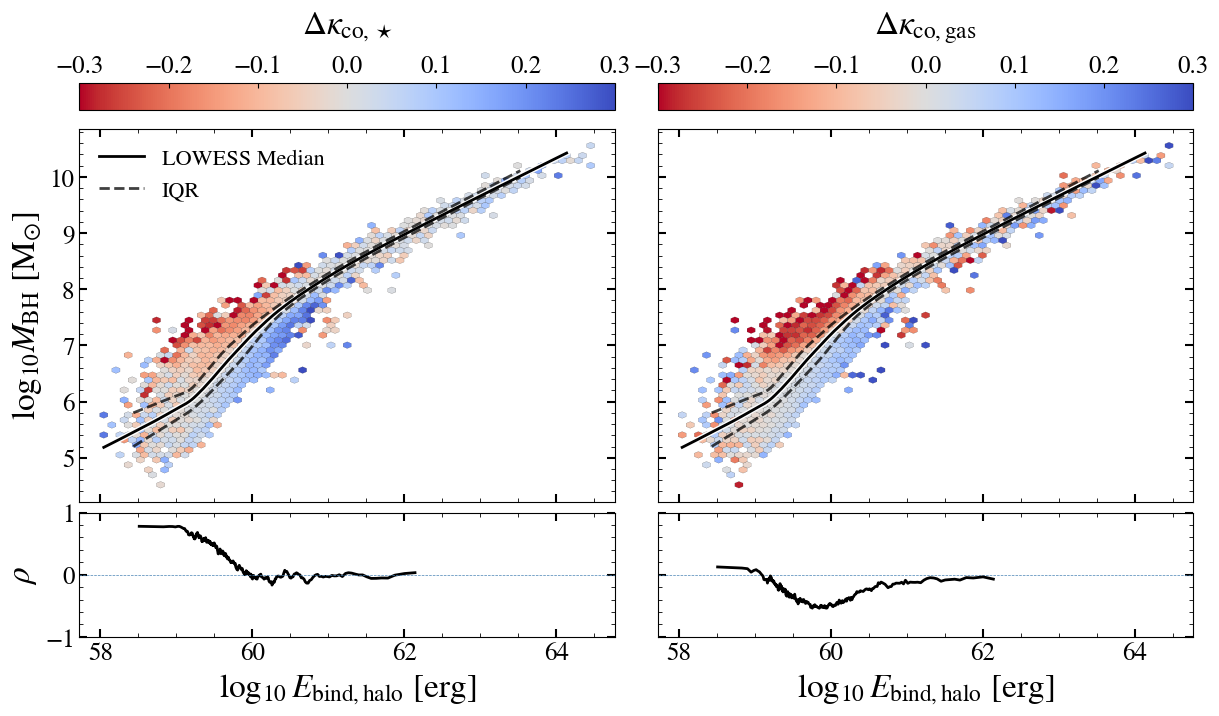

In [31]:
fig, ax = plt.subplots(2,2, figsize=(12,7), gridspec_kw={'height_ratios':[3,1]}, sharex=True, layout='compressed')

hex = ax[0,0].hexbin(X['EbindDMO'], X['MBH'], C=delta_X['KappaCoStars'], reduce_C_function=np.mean, edgecolors='k', linewidth=0.1, cmap='coolwarm_r', gridsize=60, vmin=-0.3, vmax=0.3)
cb = fig.colorbar(ax[0,0].collections[0], ax=ax[0,0], location='top')
cb.set_label('$\\Delta \\kappa_{\\rm co, \\star}$', fontsize=24, labelpad=15)
ax[0,0].plot(X['EbindDMO'][:-5], lowess_X['MBH'][:-5], lw=4, c='w')
ax[0,0].plot(X['EbindDMO'][:-5], lowess_X['MBH'][:-5], lw=2, c='k', label='LOWESS Median')
ax[0,0].plot(X['EbindDMO'][:-5], mbh_25th[:-5], lw=2, ls='--', c='k', alpha=0.75, label='IQR')
ax[0,0].plot(X['EbindDMO'][:-5], mbh_75th[:-5], lw=2, ls='--', c='k', alpha=0.75)
ax[0,0].set_ylabel('${\\rm log_{10}} M_{\\rm BH}$ [$\\rm M_{\\odot}$]')
ax[0,0].legend(fontsize=16, loc='upper left')
hex.set_rasterized(True)

ax[1,0].plot(ebind_bins, sr_arr_mstar, lw=2, c='k')
ax[1,0].axhline(0, ls='--', c='steelblue', lw=0.5)
ax[1,0].set_ylim(-1,1)
ax[1,0].set_ylabel('$\\rho$')
ax[1,0].set_xlabel('${\\rm log_{10}} \\, E_{\\rm bind, halo}$ [erg]')



hex = ax[0,1].hexbin(X['EbindDMO'], X['MBH'], C=delta_X['KappaCoGas'], reduce_C_function=np.mean, edgecolors='k', linewidth=0.1, cmap='coolwarm_r', gridsize=60, vmin=-0.3, vmax=0.3)
cb = fig.colorbar(ax[0,1].collections[0], ax=ax[0,1], location='top')
cb.set_label('$\\Delta \\kappa_{\\rm co, \\rm gas}$', fontsize=24, labelpad=15)
ax[0,1].plot(X['EbindDMO'][:-5], lowess_X['MBH'][:-5], lw=4, c='w')
ax[0,1].plot(X['EbindDMO'][:-5], lowess_X['MBH'][:-5], lw=2, c='k', label='LOWESS Median')
ax[0,1].plot(X['EbindDMO'][:-5], mbh_25th[:-5], lw=2, ls='--', c='k', alpha=0.75, label='IQR')
ax[0,1].plot(X['EbindDMO'][:-5], mbh_75th[:-5], lw=2, ls='--', c='k', alpha=0.75)
ax[0,1].tick_params(axis='y', labelleft=False)
hex.set_rasterized(True)

ax[1,1].axhline(0, ls='--', c='steelblue', lw=0.5)
ax[1,1].set_ylim(-1,1)
ax[1,1].plot(ebind_bins, sr_arr_kappa_co_gas, lw=2, c='k')
ax[1,1].tick_params(axis='y', labelleft=False)
ax[1,1].set_xlabel('${\\rm log_{10}} \\, E_{\\rm bind, halo}$ [erg]')

for a in ax.flat:
    a.xaxis.set_minor_locator(AutoMinorLocator())
    a.yaxis.set_minor_locator(AutoMinorLocator())
    a.tick_params(axis='x', which='minor', top=True, length=3)
    a.tick_params(axis='y', which='minor', right=True, length=3)
    a.tick_params(axis='x', which='major', top=True, width=1.5, length=6)
    a.tick_params(axis='y', which='major', right=True, width=1.5, length=6)
    
plt.show()